In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import kafe2
import scipy.stats as stats

from spectra.peakFitter_adapted import peakFitter

# Energy Calibration

In [13]:
# Parameterize the files

sources = ['Co57', 'Co60', 'Cs137', 'Na22']
detectors = ['NaI', 'Ge']

files = []
for source in sources:
    for detector in detectors:
        files.append(f'spectra/{source}_{detector}.npy')

In [14]:
# get the corresponding energies (i.e. from https://www.ezag.com/)
energies = [122.06, 1173.2, 1332.5, 661.61, 511.0, 1274.5] # keV

In [15]:
# initial guesses for the parameters
prominences = [500 for _ in range(8)]
widths = []
for i in range(4):
    widths.append(20) # NaI
    widths.append(1)  # Ge

In [16]:
# fine tuning of the parameters
prominences[2] = 200
widths[5]=0
prominences[6] = 40
prominences[7] = 50

mus_NaI = []
mus_Ge = []
sigmas_NaI = []
sigmas_Ge = []
for i in range(8):
    file = files[i]
    mu, sigma = peakFitter(
        filename=file, 
        smoothing_window=0, 
        min_prominence=prominences[i], 
        min_width=widths[i], 
        plot=False, # set to True to see the results
        print_results=False 
        ) 
    
    
    # sort the results in NaI and Ge detectors
    if i % 2 == 0:
        mus_NaI+=mu
        sigmas_NaI+=sigma
    else:
        mus_Ge+=mu
        sigmas_Ge+=sigma
    


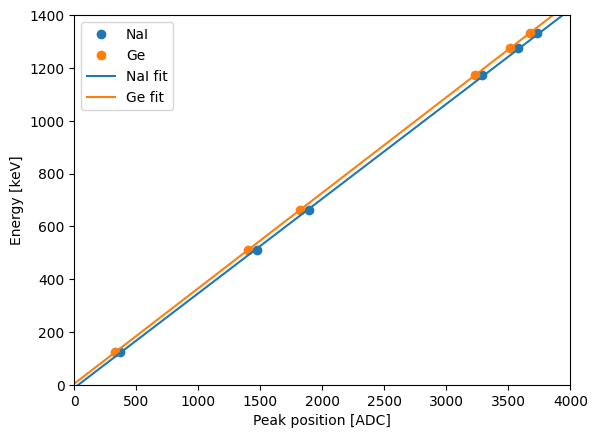

In [17]:
# Fit the resulting mus to the expected energys using the sigmas as an error.

ret_NaI = kafe2.xy_fit("line", mus_NaI, energies, x_error=sigmas_NaI, y_error=0.05)
# kafe2.plot(x_label="Peak position [ADC]", y_label="Energy [keV]", data_label="NaI")
def NaI(adc):
    return ret_NaI['parameter_values']['a']*adc + ret_NaI['parameter_values']['b']


ret_Ge = kafe2.xy_fit("line", mus_Ge, energies, x_error=sigmas_Ge, y_error=0.05)
# kafe2.plot(x_label="Peak position [ADC]", y_label="Energy [keV]", data_label="Ge")
def Ge(adc):
    return ret_Ge['parameter_values']['a']*adc + ret_Ge['parameter_values']['b']

plt.plot(mus_NaI, energies, 'o', label='NaI', color="tab:blue")
plt.plot(mus_Ge, energies, 'o', label='Ge', color="tab:orange")

x = np.linspace(0, 4000, 100)
plt.plot(x, NaI(x), label='NaI fit', color="tab:blue")
plt.plot(x, Ge(x), label='Ge fit', color="tab:orange")
plt.xlabel('Peak position [ADC]')
plt.ylabel('Energy [keV]')
plt.xlim(0, 4000)
plt.ylim(0, 1400)
plt.legend()
plt.show()

# Coincidence

In [18]:
# get relevant peak information

# Na22: 511 peak
Na_NaI = (mus_NaI[4], sigmas_NaI[4])
Na_Ge = (mus_Ge[4], sigmas_Ge[4])

# Co60: 1173 peak
Co1_NaI = (mus_NaI[1], sigmas_NaI[1])
Co1_Ge = (mus_Ge[1], sigmas_Ge[1])

# Co60: 1332 peak
Co2_NaI = (mus_NaI[2], sigmas_NaI[2])
Co2_Ge = (mus_Ge[2], sigmas_Ge[2])

- Define Signal and Background PDF:
$\begin{align}
\mathrm{pdf}_\mathrm{Signal}(\Delta, \mu, \sigma, a, b) &= \dfrac{\mathrm{norm.pdf}(\Delta,\mu,\sigma)}{\mathrm{norm.cdf}(b,\mu,\sigma)-\mathrm{norm.cdf}(a,\mu,\sigma)}\\
\mathrm{pdf}_\mathrm{Background}(\Delta, a, b) &= \dfrac{1}{b-a}\\
\mathrm{pdf}_\mathrm{Combined}(\Delta, \mu, \sigma, a, b, r) &= (1-r)\cdot\mathrm{pdf}_\mathrm{Background} + r\cdot\mathrm{pdf}_\mathrm{Signal}
\end{align}$

In [19]:
def pdf_signal(x, mu, sigma, a, b):
    return stats.norm.pdf(x, mu, sigma) / (stats.norm.cdf(b, mu, sigma) - stats.norm.cdf(a, mu, sigma))

def pdf_background(x, a, b):
    return 1/(b-a) 

def pdf_combined(x, mu, sigma, a, b, r):
    return r*pdf_signal(x, mu, sigma, a, b) + (1-r)*pdf_background(x, a, b)

In [20]:
A = -400
B = 800

/home/julian/miniconda3/lib/python3.12/site-packages/kafe2/fit/histogram/container.py:94: UserWarning: Histogram data is int. Make sure to consider this for your bin edges!
  warnings.warn("Histogram data is int. Make sure to consider this for your bin edges!")


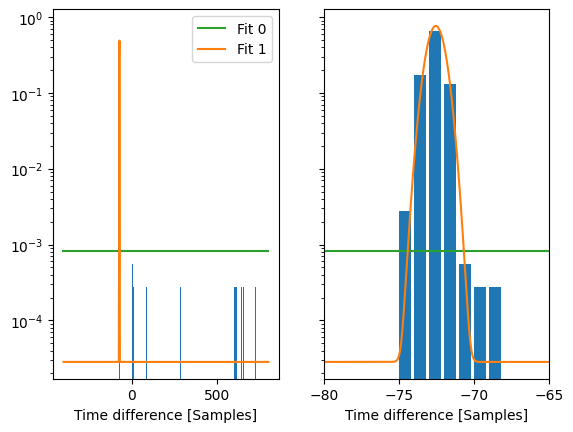

[{'did_fit': True,
  'cost': 43700.649258414196,
  'ndf': 1197,
  'goodness_of_fit': np.float64(43434.43823124503),
  'gof/ndf': np.float64(36.286080393688415),
  'chi2_probability': None,
  'parameter_values': OrderedDict([('mu', np.float64(-65.0000143051102)),
               ('sigma', np.float64(1.0000000000000002)),
               ('a', np.float64(-400.0)),
               ('b', np.float64(800.0)),
               ('r', np.float64(0.0))]),
  'parameter_cov_mat': None,
  'parameter_errors': OrderedDict([('mu', np.float64(0.0)),
               ('sigma', np.float64(0.0)),
               ('a', np.float64(0.0)),
               ('b', np.float64(0.0)),
               ('r', np.float64(0.0))]),
  'parameter_cor_mat': None,
  'asymmetric_parameter_errors': None},
 {'did_fit': True,
  'cost': 852.9739307779087,
  'ndf': 1196,
  'goodness_of_fit': np.float64(586.7629036087432),
  'gof/ndf': np.float64(0.49060443445547086),
  'chi2_probability': None,
  'parameter_values': OrderedDict([('mu', np.f

In [ ]:
import kafe2
import scipy.stats as stats

N_SIGMA_PEAK = 1

def pdf_signal(x, mu, sigma, a, b):
    return stats.norm.pdf(x, mu, sigma) / (stats.norm.cdf(b, mu, sigma) - stats.norm.cdf(a, mu, sigma))

def pdf_background(x, a, b):
    return 1/(b-a) 

def pdf_combined(x, mu, sigma, a, b, r):
    return r*pdf_signal(x, mu, sigma, a, b) + (1-r)*pdf_background(x, a, b)


def coincidenceFitter(data, a, b, peak_1, peak_2, sigma_limit, mu_range, kafe2plot = False, plot = True):
    # filter data
    peak1_lower = peak_1[0]-N_SIGMA_PEAK*peak_1[1]
    peak1_upper = peak_1[0]+N_SIGMA_PEAK*peak_1[1]
    mask1 = (data['height_1'] > peak1_lower) & (data['height_1'] < peak1_upper)
    
    peak2_lower = peak_2[0]-N_SIGMA_PEAK*peak_2[1]
    peak2_upper = peak_2[0]+N_SIGMA_PEAK*peak_2[1]
    mask2 = (data['height_2'] > peak2_lower) & (data['height_2'] < peak2_upper)
    
    time_differences = data[mask1 & mask2]['time_difference']
    
    bin_edges = np.arange(a,b)
    container = kafe2.HistContainer(bin_edges = bin_edges, fill_data = time_differences)

        
    fit0 = kafe2.Fit(container, pdf_combined)
    fit0.fix_parameter('r', 0)
    
    fit1 = kafe2.Fit(container, pdf_combined)
    fit1.limit_parameter('r', 0, 1)
    
    fits = [fit0, fit1]
    
    rets = []
    n2lnLs = []
    parameters = []
    for fit in fits:
        fit.fix_parameter('a', a)
        fit.fix_parameter('b', b)
        fit.limit_parameter('mu', mu_range[0], mu_range[1])
        fit.limit_parameter('sigma', 0, sigma_limit)
        ret = fit.do_fit()
        rets.append(ret)
        n2lnLs.append(ret['cost'])
        parameters.append(ret['parameter_values'])
        
    def pdf0(x):
        return pdf_combined(x, **parameters[0])
    
    def pdf1(x):
        return pdf_combined(x, **parameters[1])
        
    if kafe2plot:
        plot = kafe2.Plot(fits)
        plot.plot()
        plt.show()
        
    if plot:
        hist, _ = np.histogram(time_differences, bins=bin_edges, density=True)
        x = np.linspace(a, b, 1000)
        x_zoomed = np.linspace(mu_range[0], mu_range[1], 1000)
        
        fix, axs = plt.subplots(1, 2, sharey=True)
        axs[0].set_yscale('log')
        
        for ax in axs:
            ax.bar(bin_edges[:-1], hist, width=.8, align='edge', label='Data')
            ax.set_xlabel('Time difference [Samples]')
        
        axs[0].plot(x, pdf0(x), label='Fit 0', color='tab:green')
        axs[0].plot(x, pdf1(x), label='Fit 1', color='tab:orange')
        
        axs[1].plot(x_zoomed, pdf0(x_zoomed), label='Fit 0', color='tab:green')
        axs[1].plot(x_zoomed, pdf1(x_zoomed), label='Fit 1', color='tab:orange')
        
        axs[1].set_xlim(mu_range)
        axs[0].legend()
            
        plt.show()
        
    return rets
    
    
    
    
    
    
    
coincidenceFitter(pd.read_csv("coincidences/Na22_Coincidences.csv"), A, B, peak_1 = Na_Ge, peak_2 = Na_NaI, sigma_limit=10, mu_range=(-80,-65))

In [ ]:
def do_fits(data, mu_Ge, sigma_Ge, mu_NaI, sigma_NaI, titel):
    # create subset of the data
    mask1 = (data['height_1'] > mu_Ge - N_SIGMAS*sigma_Ge) & (data['height_1'] < mu_Ge + N_SIGMAS*sigma_Ge)
    mask2 = (data['height_2'] > mu_NaI - N_SIGMAS*sigma_NaI) & (data['height_2'] < mu_NaI + N_SIGMAS*sigma_NaI)
    mask = mask1 & mask2
    time_differences = data[mask]['time_difference']
    
    container = kafe2.UnbinnedContainer(time_differences)
    
    eps = 1e-9
    
    # fit background
    fit0 = kafe2.Fit(container, pdf_combined)
    fit0.fix_parameter('a', A)
    fit0.fix_parameter('b', B)
    fit0.fix_parameter('r', 0)
    ret0 = fit0.do_fit()
    n2lnL0 = ret0['cost']
    
    # fit signal+background
    fit1 = kafe2.Fit(container, pdf_combined)
    fit1.limit_parameter('r', 0, 1)
    #fit1.limit_parameter('mu', A, B)
    fit1.limit_parameter('mu', -75, -71)
    fit1.limit_parameter('sigma', 0, 10)
    fit1.fix_parameter('a', A)
    fit1.fix_parameter('b', B)
    
    ret1 = fit1.do_fit()
    mu1 = ret1['parameter_values']['mu']
    sigma1 = ret1['parameter_values']['sigma']
    r1 = ret1['parameter_values']['r']
    n2lnL1 = ret1['cost']
    
    z = np.sqrt(n2lnL0-n2lnL1)
    
    # create plots
    fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    fig.suptitle(titel)
    
    axs[0].hist(time_differences, bins=np.arange(A, B), histtype='step', align='left', density=True, label='Data')
    axs[1].hist(time_differences, bins=np.arange(mu1 - N_ZOOMED*sigma1, mu1 + N_ZOOMED*sigma1), histtype='bar', align='left', rwidth=0.8, density=True)
    
    x0 = np.linspace(A, B, 1000)
    axs[0].plot(x0, pdf_combined(x0, mu1, sigma1, A, B, r1), label='Signal+Background')
    axs[0].plot(x0, pdf_combined(x0, mu1, sigma1, A, B, 0), label='Background')
    x1 = np.linspace(mu1 - N_ZOOMED*sigma1, mu1 + N_ZOOMED*sigma1, 1000)
    axs[1].plot(x1, pdf_combined(x1, mu1, sigma1, A, B, r1))
    axs[1].plot(x1, pdf_combined(x1, mu1, sigma1, A, B, 0))
    
    
    axs[0].set_yscale('log')
    axs[0].legend(title=f'Significance: {z:.2f}')
    
    axs[0].set_ylabel('Density')
    axs[0].set_xlabel('Time difference [Samples]')
    axs[1].set_xlabel('Time difference [Samples]')
    fig.tight_layout()
    
    plt.show()
    
    
    

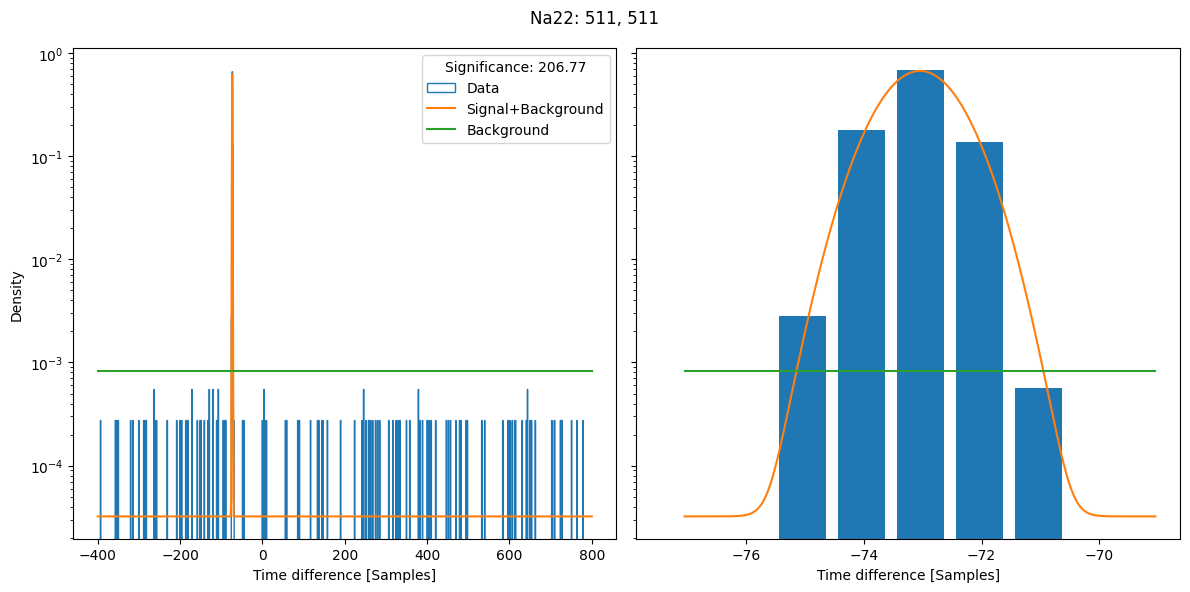

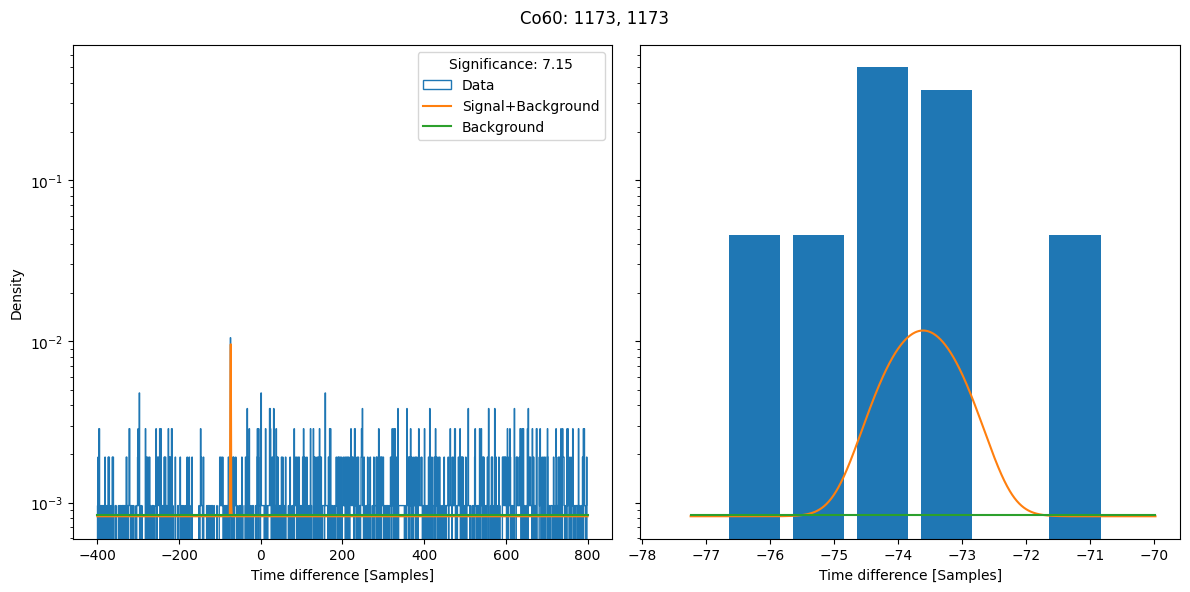

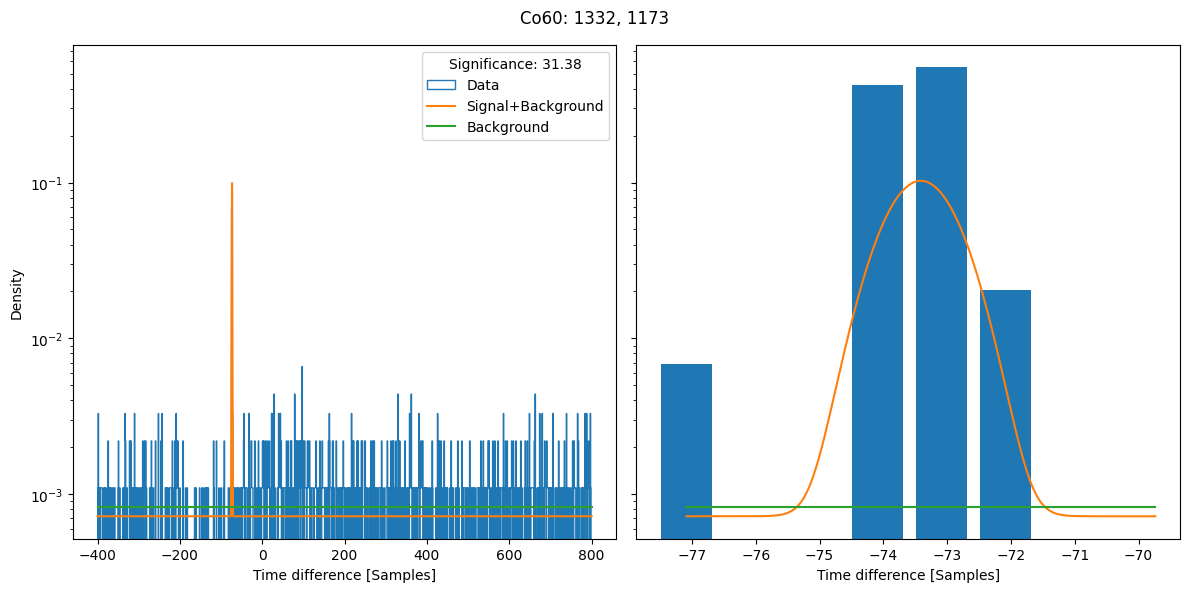

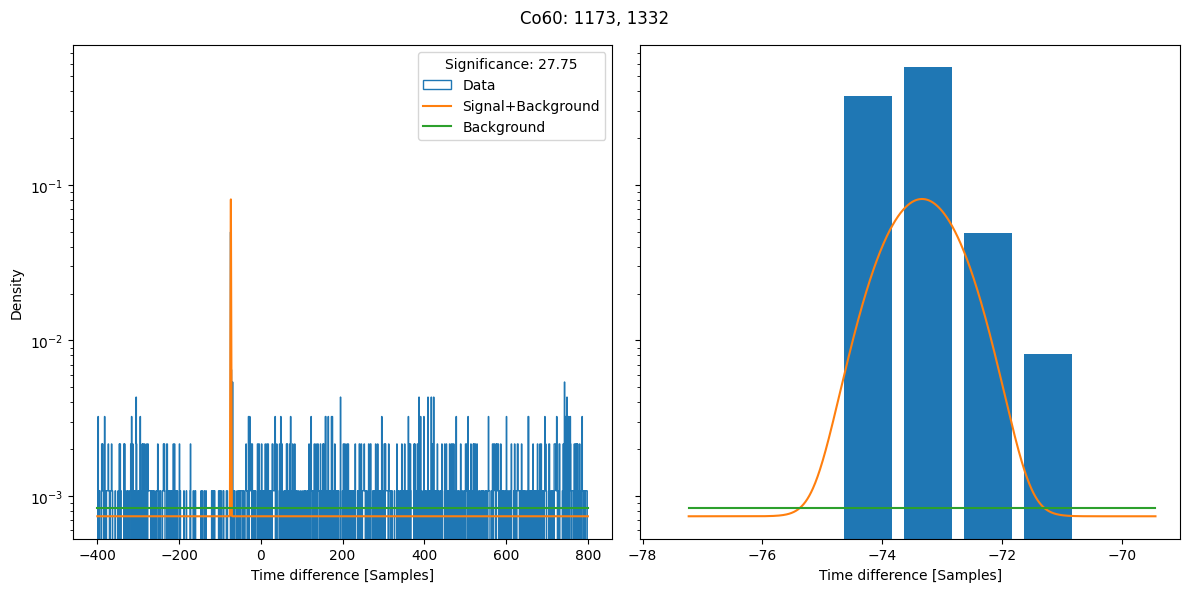

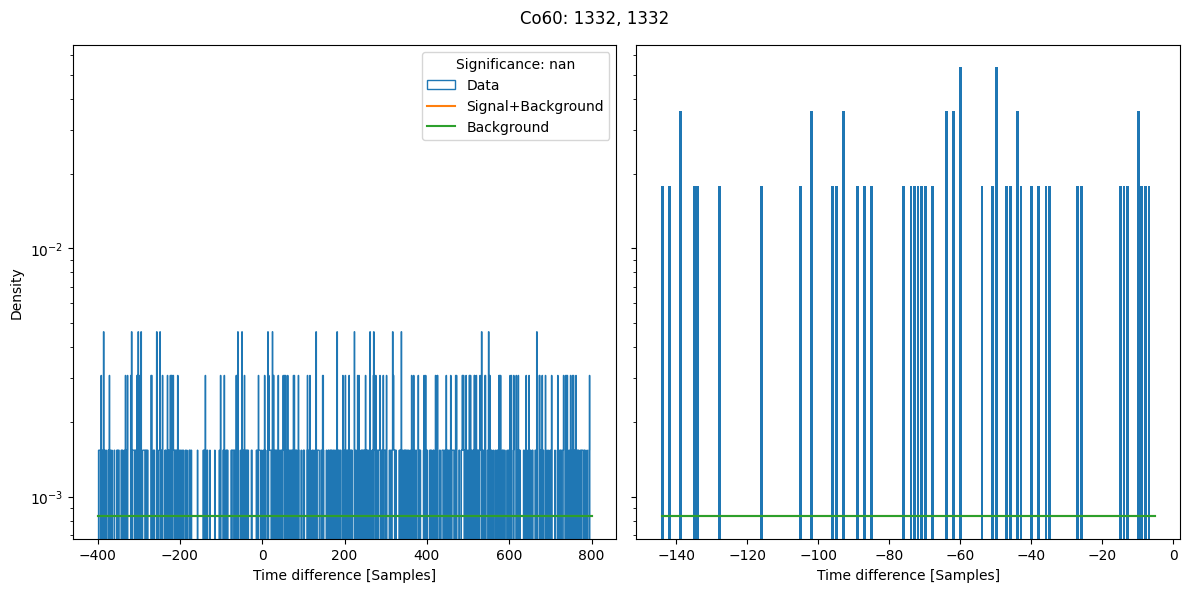

In [ ]:
import warnings
warnings.filterwarnings('ignore')

do_fits(pd.read_csv('coincidences/Na22_Coincidences.csv'), Na_mu_Ge, Na_sigma_Ge, Na_mu_NaI, Na_sigma_NaI, 'Na22: 511, 511')
do_fits(pd.read_csv('coincidences/Co60_Coincidence.csv'), Co1_mu_Ge, Co1_sigma_Ge, Co1_mu_NaI, Co1_sigma_NaI, 'Co60: 1173, 1173')
do_fits(pd.read_csv('coincidences/Co60_Coincidence.csv'), Co2_mu_Ge, Co2_sigma_Ge, Co1_mu_NaI, Co1_sigma_NaI, 'Co60: 1332, 1173')
do_fits(pd.read_csv('coincidences/Co60_Coincidence.csv'), Co1_mu_Ge, Co1_sigma_Ge, Co2_mu_NaI, Co2_sigma_NaI, 'Co60: 1173, 1332')
do_fits(pd.read_csv('coincidences/Co60_Coincidence.csv'), Co2_mu_Ge, Co2_sigma_Ge, Co2_mu_NaI, Co2_sigma_NaI, 'Co60: 1332, 1332')